# Production workflow: Data Quality, Profiling, and Anomaly Detection

This notebook implements a 3-layer framework:
1. Data Quality Checks
2. Statistical Profiling
3. Anomaly Detection

In [61]:
%pip install pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [63]:
CORRUPTED_PATH = Path('../data/generated/corrupted_dataset.csv')
CLEANED_OUTPUT_PATH = Path('../data/generated/cleaned_dataset1.csv')

if not CORRUPTED_PATH.exists():
    raise FileNotFoundError(f'Input dataset not found: {CORRUPTED_PATH}')

telemetry_df = pd.read_csv(CORRUPTED_PATH)
source_name = str(CORRUPTED_PATH)

print('Loaded:', source_name)
print('Shape:', telemetry_df.shape)
telemetry_df.head()

Loaded: ..\data\generated\corrupted_dataset.csv
Shape: (824, 20)


,run_id,event_ts,device_id,device_name,storage_tier,soc_model,read_iops,write_iops,read_throughput_mb_s,write_throughput_mb_s,latency_read_p99_ms,latency_write_p99_ms,utilization_pct,nvme_queue_depth,cpu_usage_pct,memory_usage_pct,io_wait_pct,host_writes_mb,nand_writes_mb,thermal_throttling_events
0,97434323-ccb3-4281-8945-636104bc5c14,2026-04-15T17:58:22.703016+00:00,iPhone_1687,unknown,1TB,A15,bad_data,473.976528,95.2655635292628,106.264820,23.71627085601721,33.25892560983117,51.689805854226115,NaN,62.333716,73.2803289509352,14.357144,331.179777,534.313085,0.0
1,a48c80a2-ad46-426e-8102-ee52d707ae16,2026-04-15T20:03:22.703016+00:00,Apple Watch_5661,Apple Watch Ultra,128GB,M1,9999999,639.728926,126.77272029254257,118.941879,bad_data,34.96672169215888,30.902697317249512,1.0,14.333113,bad_data,13.368335,134.841379,80.811053,2.0
2,97434323-ccb3-4281-8945-636104bc5c14,2026-04-15T23:08:22.703016+00:00,iPhone_1237,NaN,128GB,M2,621.1585296041045,560.538986,99.42441971470072,124.542690,bad_data,37.73066549590951,66.23409268100735,10.074455672843154,58.224071,70.05694377432188,18.593975,204.019464,319.876340,2.0
3,ffd7d286-f6c9-4320-99ff-07e25bf4d02d,2026-04-15T23:08:22.703016+00:00,iPad_9319,iPad Air M1,256GB,A15,1040.3460062079102,611.910572,126.43362263808102,NaN,87.69109296058268,155.8033028312403,82.01227179138256,12.498441793821838,95.498299,70.07181039027071,4.146582,400.650432,781.910779,bad_data
4,a48c80a2-ad46-426e-8102-ee52d707ae16,2026-04-15T21:38:22.703016+00:00,Apple Watch_6877,Apple Watch Ultra,1TB,M1,897.2090136535642,604.038885,83.53091611203955,54.507065,18.226954920913023,22.523431980709166,75.41266836509051,3.177146222747462,47.457642,58.6258539561549,11.315614,92.130461,151.156582,7.0


## Layer 1 - Data Quality Checks

In [64]:
EXPECTED_COLS = [
    'run_id', 'event_ts', 'device_id', 'device_name', 'storage_tier', 'soc_model',
    'read_iops', 'write_iops', 'read_throughput_mb_s', 'write_throughput_mb_s',
    'latency_read_p99_ms', 'latency_write_p99_ms', 'utilization_pct', 'nvme_queue_depth',
    'cpu_usage_pct', 'memory_usage_pct', 'io_wait_pct', 'host_writes_mb',
    'nand_writes_mb', 'thermal_throttling_events'
]

NUMERIC_COLS = [
    'read_iops', 'write_iops', 'read_throughput_mb_s', 'write_throughput_mb_s',
    'latency_read_p99_ms', 'latency_write_p99_ms', 'utilization_pct', 'nvme_queue_depth',
    'cpu_usage_pct', 'memory_usage_pct', 'io_wait_pct', 'host_writes_mb',
    'nand_writes_mb', 'thermal_throttling_events'
]

VALID_STORAGE = {'128GB', '256GB', '512GB', '1TB'}
VALID_SOC = {'A15', 'A16', 'A17', 'M1', 'M2'}

RANGE_RULES = {
    'cpu_usage_pct': (0, 100),
    'memory_usage_pct': (0, 100),
    'utilization_pct': (0, 100),
    'io_wait_pct': (0, 100),
    'latency_read_p99_ms': (0, None),
    'latency_write_p99_ms': (0, None),
    'read_iops': (0, None),
    'write_iops': (0, None),
    'nvme_queue_depth': (0, None),
}

In [65]:
# 1.1 Schema validation
missing_cols = sorted(set(EXPECTED_COLS) - set(telemetry_df.columns))
extra_cols = sorted(set(telemetry_df.columns) - set(EXPECTED_COLS))

coercion_report = {}
for c in NUMERIC_COLS:
    if c not in telemetry_df.columns:
        continue
    converted = pd.to_numeric(telemetry_df[c], errors='coerce')
    coercion_report[c] = {
        'null_before': int(telemetry_df[c].isna().sum()),
        'null_after': int(converted.isna().sum()),
        'bad_token_count': int(converted.isna().sum() - telemetry_df[c].isna().sum())
    }

print('Missing expected columns:', missing_cols)
print('Extra columns:', extra_cols)
pd.DataFrame(coercion_report).T.sort_values('bad_token_count', ascending=False)

Missing expected columns: []
Extra columns: []


,null_before,null_after,bad_token_count
read_iops,49,74,25
read_throughput_mb_s,49,74,25
latency_read_p99_ms,49,74,25
utilization_pct,48,73,25
thermal_throttling_events,47,72,25
latency_write_p99_ms,49,73,24
memory_usage_pct,47,71,24
nvme_queue_depth,46,70,24
write_throughput_mb_s,70,70,0
write_iops,73,73,0


Critical key device_id null %: 6.07
Average row null %: 8.08


,null_pct
host_writes_mb,8.98
latency_read_p99_ms,8.98
read_throughput_mb_s,8.98
read_iops,8.98
latency_write_p99_ms,8.86
write_iops,8.86
utilization_pct,8.86
io_wait_pct,8.74
thermal_throttling_events,8.74
nand_writes_mb,8.74


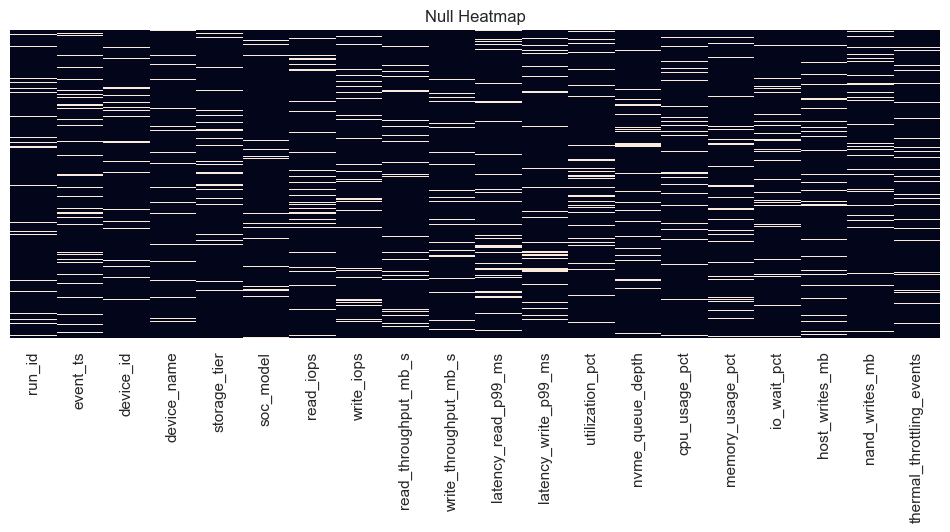

In [66]:
workload_profile = telemetry_df.copy()
for c in NUMERIC_COLS:
    if c in workload_profile.columns:
        workload_profile[c] = pd.to_numeric(workload_profile[c], errors='coerce')
workload_profile['event_ts'] = pd.to_datetime(workload_profile['event_ts'], errors='coerce', utc=True)

# 1.2 Missing data checks
col_null_pct = (workload_profile.isna().mean() * 100).sort_values(ascending=False).round(2)
row_null_pct = workload_profile.isna().mean(axis=1) * 100

print('Critical key device_id null %:', round(workload_profile['device_id'].isna().mean() * 100, 2))
print('Average row null %:', round(row_null_pct.mean(), 2))
display(col_null_pct.to_frame('null_pct'))

plt.figure(figsize=(12, 4))
sns.heatmap(workload_profile.isna(), cbar=False, yticklabels=False)
plt.title('Null Heatmap')
plt.show()

In [67]:
# 1.3 Duplicate checks
exact_dups = int(workload_profile.duplicated().sum())
pk_dups = int(workload_profile.duplicated(subset=['device_id', 'event_ts']).sum())

near_dups = 0
ts_ok = workload_profile.dropna(subset=['device_id', 'event_ts']).sort_values(['device_id', 'event_ts']).copy()
if not ts_ok.empty:
    delta = ts_ok.groupby('device_id')['event_ts'].diff().abs().dt.total_seconds()
    near_dups = int(((delta > 0) & (delta <= 5)).sum())

print('Exact duplicates:', exact_dups)
print('Primary key duplicates (device_id,event_ts):', pk_dups)
print('Near duplicates (same device within 5s):', near_dups)

Exact duplicates: 24
Primary key duplicates (device_id,event_ts): 27
Near duplicates (same device within 5s): 0


In [68]:
# 1.4 Range checks + 1.5 categorical checks + 1.6 timestamp checks
range_issues = []
for col, (lo, hi) in RANGE_RULES.items():
    if col not in workload_profile.columns:
        continue
    bad = pd.Series(False, index=workload_profile.index)
    if lo is not None:
        bad = bad | (workload_profile[col] < lo)
    if hi is not None:
        bad = bad | (workload_profile[col] > hi)
    range_issues.append({'column': col, 'violations': int(bad.fillna(False).sum())})

cat_issues = {
    'soc_model_invalid': int((~workload_profile['soc_model'].isin(VALID_SOC)).fillna(True).sum()),
    'storage_tier_invalid': int((~workload_profile['storage_tier'].isin(VALID_STORAGE)).fillna(True).sum()),
}

ts_parsed_pct = round(workload_profile['event_ts'].notna().mean() * 100, 2)
now_utc = pd.Timestamp.utcnow().tz_localize('UTC') if pd.Timestamp.utcnow().tzinfo is None else pd.Timestamp.utcnow()
future_ts = int((workload_profile['event_ts'] > now_utc).fillna(False).sum())
old_ts = int((workload_profile['event_ts'] < pd.Timestamp('2000-01-01', tz='UTC')).fillna(False).sum())

display(pd.DataFrame(range_issues).sort_values('violations', ascending=False))
print('Categorical issues:', cat_issues)
print('Timestamp parse success %:', ts_parsed_pct)
print('Future timestamps:', future_ts)
print('Very old timestamps:', old_ts)

C:\Users\rakes\AppData\Local\Temp\ipykernel_8404\952319183.py:19: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now_utc = pd.Timestamp.utcnow().tz_localize('UTC') if pd.Timestamp.utcnow().tzinfo is None else pd.Timestamp.utcnow()


,column,violations
3,io_wait_pct,18
4,latency_read_p99_ms,17
0,cpu_usage_pct,16
2,utilization_pct,16
1,memory_usage_pct,0
5,latency_write_p99_ms,0
6,read_iops,0
7,write_iops,0
8,nvme_queue_depth,0


Categorical issues: {'soc_model_invalid': 75, 'storage_tier_invalid': 75}
Timestamp parse success %: 91.87
Future timestamps: 3
Very old timestamps: 0


In [69]:
# 4.1 Data Quality Score
completeness = (1 - workload_profile.isna().mean().mean()) * 100
validity = 100 - (pd.DataFrame(range_issues)['violations'].sum() / max(len(workload_profile) * max(len(range_issues), 1), 1) * 100)
uniqueness = (1 - (exact_dups / max(len(workload_profile), 1))) * 100
consistency = 100 - ((cat_issues['soc_model_invalid'] + cat_issues['storage_tier_invalid']) / max(2 * len(workload_profile), 1) * 100)
dq_score = (completeness + validity + uniqueness + consistency) / 4

dq = pd.DataFrame([
    {'component': 'completeness', 'score': round(completeness, 2)},
    {'component': 'validity', 'score': round(validity, 2)},
    {'component': 'uniqueness', 'score': round(uniqueness, 2)},
    {'component': 'consistency', 'score': round(consistency, 2)},
    {'component': 'overall_dq_score', 'score': round(dq_score, 2)},
])
dq

,component,score
0,completeness,91.92
1,validity,99.10
2,uniqueness,97.09
3,consistency,90.90
4,overall_dq_score,94.75


## Layer 2 - Statistical Profiling

In [70]:
import sys
import importlib
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import src.features.feature_engineering as feature_engineering
importlib.reload(feature_engineering)
build_features = feature_engineering.build_features

# Apply all feature engineering — replaces the inline feature block
workload_profile = build_features(workload_profile)

# Persist the enriched + cleaned dataset
workload_profile.to_csv(CLEANED_OUTPUT_PATH, index=False)
print('Saved enriched dataset to:', CLEANED_OUTPUT_PATH)
print('New feature columns:', [
    'write_amplification', 'throughput_per_iop', 'saturation_score',
    'total_iops', 'io_mix', 'cpu_to_io_ratio', 'io_wait_to_latency_ratio',
    'rolling_mean_latency', 'rolling_std_latency',
    'rolling_mean_iops', 'rolling_std_iops', 'burstiness',
])

profile_cols = [
    'read_iops', 'write_iops', 'latency_read_p99_ms', 'latency_write_p99_ms',
    'cpu_usage_pct', 'io_wait_pct', 'total_iops', 'io_mix',
    'write_amplification', 'throughput_per_iop', 'saturation_score',
    'cpu_to_io_ratio', 'io_wait_to_latency_ratio', 'burstiness',
]

distribution_summary = workload_profile[profile_cols].describe(percentiles=[0.5, 0.95, 0.99]).T
distribution_summary[['mean', '50%', 'std', 'min', '95%', '99%', 'max']]

Saved enriched dataset to: ..\data\generated\cleaned_dataset1.csv
New feature columns: ['write_amplification', 'throughput_per_iop', 'saturation_score', 'total_iops', 'io_mix', 'cpu_to_io_ratio', 'io_wait_to_latency_ratio', 'rolling_mean_latency', 'rolling_std_latency', 'rolling_mean_iops', 'rolling_std_iops', 'burstiness']


,mean,50%,std,min,95%,99%,max
read_iops,227440.091679,797.710708,1.489260e+06,10.000000,1193.907631,9.999999e+06,9.999999e+06
write_iops,602.816104,603.434769,1.481646e+02,139.045459,846.492322,9.481361e+02,1.085024e+03
latency_read_p99_ms,35.446393,21.769278,3.382202e+01,-10.000000,111.249038,1.414849e+02,1.581160e+02
latency_write_p99_ms,51.665193,32.217451,4.334298e+01,12.830890,149.645461,1.780415e+02,1.999179e+02
cpu_usage_pct,62.780048,60.026797,2.924663e+01,5.000000,96.623791,2.000000e+02,2.000000e+02
io_wait_pct,10.712454,9.875862,8.373330e+00,-5.000000,24.175099,4.725839e+01,5.325526e+01
total_iops,235636.716692,1404.958503,1.513517e+06,408.176714,1878.516548,1.000068e+07,1.000081e+07
io_mix,0.573506,0.569703,1.121883e-01,0.014063,0.734175,9.999340e-01,9.999707e-01
write_amplification,3.546784,1.520180,1.580379e+01,0.005669,3.349876,9.132512e+01,1.921702e+02
throughput_per_iop,0.150760,0.146585,5.156246e-02,0.000016,0.243136,3.022335e-01,3.756210e-01


In [71]:
# 2.2 Skew detection
skew_df = pd.DataFrame({
    'mean': workload_profile[profile_cols].mean(),
    'median': workload_profile[profile_cols].median(),
})
skew_df['mean_minus_median'] = skew_df['mean'] - skew_df['median']
skew_df['mean_to_median_ratio'] = skew_df['mean'] / skew_df['median'].replace(0, np.nan)
skew_df.sort_values('mean_minus_median', ascending=False)

,mean,median,mean_minus_median,mean_to_median_ratio
total_iops,235636.716692,1404.958503,234231.758188,167.717919
read_iops,227440.091679,797.710708,226642.380971,285.116007
saturation_score,870.267729,371.780647,498.487082,2.340810
latency_write_p99_ms,51.665193,32.217451,19.447742,1.603640
latency_read_p99_ms,35.446393,21.769278,13.677115,1.628276
cpu_to_io_ratio,12.413319,5.969452,6.443866,2.079474
cpu_usage_pct,62.780048,60.026797,2.753251,1.045867
write_amplification,3.546784,1.520180,2.026604,2.333135
burstiness,2.066391,0.215340,1.851051,9.595955
io_wait_pct,10.712454,9.875862,0.836593,1.084711


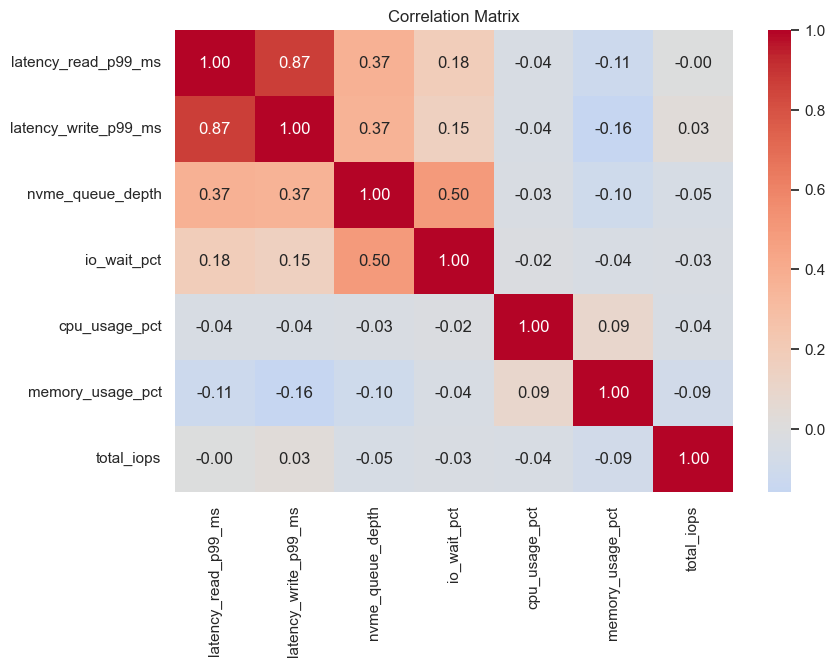

,latency_read_p99_ms,latency_write_p99_ms,nvme_queue_depth,io_wait_pct,cpu_usage_pct,memory_usage_pct,total_iops
latency_read_p99_ms,1.000000,0.871940,0.369717,0.183356,-0.043002,-0.114271,-0.004653
latency_write_p99_ms,0.871940,1.000000,0.366218,0.154570,-0.044059,-0.158816,0.028541
nvme_queue_depth,0.369717,0.366218,1.000000,0.495096,-0.031441,-0.100548,-0.053548
io_wait_pct,0.183356,0.154570,0.495096,1.000000,-0.015014,-0.037441,-0.034958
cpu_usage_pct,-0.043002,-0.044059,-0.031441,-0.015014,1.000000,0.086783,-0.038202
memory_usage_pct,-0.114271,-0.158816,-0.100548,-0.037441,0.086783,1.000000,-0.085564
total_iops,-0.004653,0.028541,-0.053548,-0.034958,-0.038202,-0.085564,1.000000


In [72]:
# 2.3 Correlation matrix
corr_cols = ['latency_read_p99_ms', 'latency_write_p99_ms', 'nvme_queue_depth', 'io_wait_pct', 'cpu_usage_pct', 'memory_usage_pct', 'total_iops']
corr = workload_profile[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

corr

In [73]:
# 2.4 Grouped profiling
group_profile = workload_profile.groupby(['device_name', 'soc_model', 'storage_tier'], dropna=False)[['total_iops', 'latency_read_p99_ms', 'latency_write_p99_ms', 'write_amplification']].agg(['mean', 'median', 'count'])
group_profile.sort_values(('total_iops', 'mean'), ascending=False).head(20)

total_iops                      \
                                                  mean        median count   
device_name       soc_model storage_tier                                     
iPhone 14 Pro     M1        128GB         1.000069e+07  1.000069e+07     1   
iPad Air M1       M9        128GB         6.667452e+06  1.000052e+07     3   
iPad Pro M2       NaN       256GB         5.001047e+06  5.001047e+06     2   
unknown           M2        512GB         5.000990e+06  5.000990e+06     2   
Apple Watch Ultra M1        128GB         5.000950e+06  5.000950e+06     2   
iPad Pro M2       A16       128GB         3.334604e+06  1.890865e+03     3   
iPhone 14 Pro     M2        512GB         3.334568e+06  1.580559e+03     3   
Apple Watch Ultra A17       512GB         3.334552e+06  1.529753e+03     3   
iPad Pro M2       A15       1TB           3.334339e+06  1.289468e+03     3   
                  A17       128GB         2.501303e+06  1.600695e+03     4   
MacBook Pro M2    M1        256GB         2.001366e+06  1.511744e+03     5   
iPad Air M1       A17       256GB         2.001189e+06  1.456806e+03     5   
iPad Pro M2       M1        256GB         1.667877e+06  1.412652e+03     6   
                            1TB           1.667774e+06  1.263513e+03     6   
Mac Mini M2       A15       1TB           1.429944e+06  1.502295e+03     7   
iPhone 14 Pro     M9        NaN           2.203143e+03  2.203143e+03     1   
iPhone 15         A16       512GB         1.878766e+03  1.878766e+03     1   
                  NaN       1TB           1.797104e+03  1.797104e+03     1   
                  M2        NaN           1.782163e+03  1.698586e+03     3   
Mac Mini M2       M2        128GB         1.765935e+03  1.765935e+03     1   

                                         latency_read_p99_ms              \
                                                        mean      median   
device_name       soc_model storage_tier                                   
iPhone 14 Pro     M1        128GB                  24.158769   24.158769   
iPad Air M1       M9        128GB                  75.745086  104.600050   
iPad Pro M2       NaN       256GB                  50.771130   50.771130   
unknown           M2        512GB                  19.967384   19.967384   
Apple Watch Ultra M1        128GB                  11.368084   11.368084   
iPad Pro M2       A16       128GB                  62.206854   25.896812   
iPhone 14 Pro     M2        512GB                  19.391431   18.985430   
Apple Watch Ultra A17       512GB                  51.942666   26.470802   
iPad Pro M2       A15       1TB                    18.618627   18.655030   
                  A17       128GB                  37.684593   22.405728   
MacBook Pro M2    M1        256GB                  23.989593   23.935422   
iPad Air M1       A17       256GB                  27.546706   21.108095   
iPad Pro M2       M1        256GB                  18.863350   18.574845   
                            1TB                    55.441468   54.251166   
Mac Mini M2       A15       1TB                    67.052010   56.674768   
iPhone 14 Pro     M9        NaN                          NaN         NaN   
iPhone 15         A16       512GB                  17.008123   17.008123   
                  NaN       1TB                    14.056185   14.056185   
                  M2        NaN                    11.037968   10.459348   
Mac Mini M2       M2        128GB                  18.826003   18.826003   

                                               latency_write_p99_ms  \
                                         count                 mean   
device_name       soc_model storage_tier                              
iPhone 14 Pro     M1        128GB            2            23.908131   
iPad Air M1       M9        128GB            3           144.991085   
iPad Pro M2       NaN       256GB            2            83.017480   
unknown           M2        512GB            2            41.173926   
App

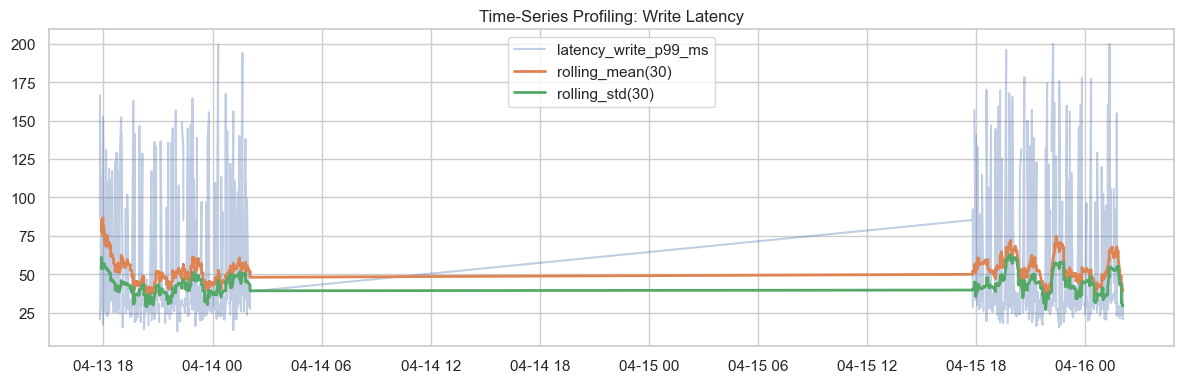

In [74]:
# 2.5 Time-series profiling
ts = workload_profile.dropna(subset=['event_ts']).sort_values('event_ts').copy()
ts = ts.set_index('event_ts')

roll_mean = ts['latency_write_p99_ms'].rolling(30, min_periods=5).mean()
roll_std = ts['latency_write_p99_ms'].rolling(30, min_periods=5).std()

plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts['latency_write_p99_ms'], alpha=0.35, label='latency_write_p99_ms')
plt.plot(roll_mean.index, roll_mean, label='rolling_mean(30)', linewidth=2)
plt.plot(roll_std.index, roll_std, label='rolling_std(30)', linewidth=2)
plt.title('Time-Series Profiling: Write Latency')
plt.legend()
plt.tight_layout()
plt.show()

## Layer 3 - Anomaly Detection

In [75]:
anom = workload_profile.copy()

# 3.1 Rule-based
anom['rule_high_write_latency'] = anom['latency_write_p99_ms'] > 100
anom['rule_high_cpu'] = anom['cpu_usage_pct'] > 95
anom['rule_io_contention'] = anom['io_wait_pct'] > 30

# 3.2 Z-score baseline
z_cols = ['latency_write_p99_ms', 'latency_read_p99_ms', 'cpu_usage_pct', 'io_wait_pct', 'total_iops']
for c in z_cols:
    mu = anom[c].mean()
    sd = anom[c].std()
    anom[f'z_{c}'] = (anom[c] - mu) / (sd if pd.notna(sd) and sd != 0 else np.nan)

anom['zscore_anomaly'] = anom[[f'z_{c}' for c in z_cols]].abs().max(axis=1) > 3

# 3.3 Multivariate rules
anom['disk_issue'] = (anom['latency_write_p99_ms'] > 80) & (anom['io_wait_pct'] > 20)
anom['compute_issue'] = (anom['latency_write_p99_ms'] > 80) & (anom['cpu_usage_pct'] > 85)
anom['suspicious_low_signal_high_latency'] = (anom['latency_write_p99_ms'] > 80) & (anom['cpu_usage_pct'] < 40) & (anom['io_wait_pct'] < 10)

anom['is_anomaly'] = anom[[
    'rule_high_write_latency', 'rule_high_cpu', 'rule_io_contention',
    'zscore_anomaly', 'disk_issue', 'compute_issue', 'suspicious_low_signal_high_latency'
]].any(axis=1)

anom['root_cause'] = np.select(
    [anom['disk_issue'], anom['compute_issue'], anom['suspicious_low_signal_high_latency']],
    ['disk', 'compute', 'suspicious'],
    default='other_or_normal'
)

column_statistics = {
    'total_rows': len(anom),
    'anomaly_rows': int(anom['is_anomaly'].sum()),
    'anomaly_rate_pct': round(anom['is_anomaly'].mean() * 100, 2),
}
print(column_statistics)
anom['root_cause'].value_counts()

{'total_rows': 824, 'anomaly_rows': 206, 'anomaly_rate_pct': np.float64(25.0)}


root_cause
other_or_normal    709
compute             48
disk                35
suspicious          32
Name: count, dtype: int64

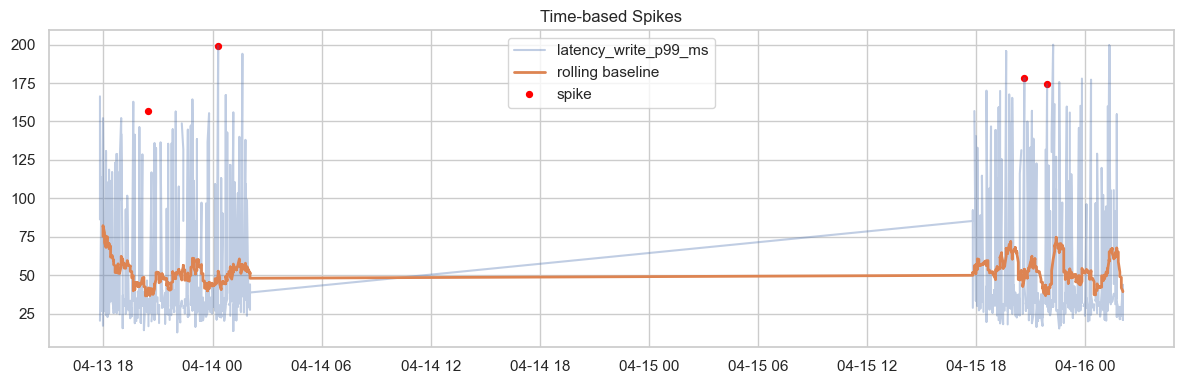

Time-based spikes: 4


In [76]:
# 3.4 Time-based anomaly spikes
if anom['event_ts'].notna().any():
    t = anom.dropna(subset=['event_ts']).sort_values('event_ts').set_index('event_ts')
    latency = t['latency_write_p99_ms']
    baseline = latency.rolling(30, min_periods=10).mean()
    spread = latency.rolling(30, min_periods=10).std()
    t['time_spike'] = latency > (baseline + 3 * spread)

    plt.figure(figsize=(12, 4))
    plt.plot(t.index, latency, alpha=0.35, label='latency_write_p99_ms')
    plt.plot(t.index, baseline, label='rolling baseline', linewidth=2)
    plt.scatter(t.index[t['time_spike']], latency[t['time_spike']], color='red', s=18, label='spike')
    plt.title('Time-based Spikes')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Time-based spikes:', int(t['time_spike'].sum()))
else:
    print('No parseable timestamps available for time-based anomalies.')

In [77]:
out_path = Path('../data/generated/anomaly_detection_output.csv')
anom.to_csv(out_path, index=False)
print('Saved anomaly output to:', out_path)

Saved anomaly output to: ..\data\generated\anomaly_detection_output.csv


## Layer 4 - Root Cause Analysis

Applies the rule-based root cause engine to classify *why* each anomalous row
is anomalous, producing a `root_cause_label` and a `confidence_score`.

| Label | Condition |
|---|---|
| `disk_bottleneck` | latency high **and** io_wait high |
| `cpu_bottleneck` | latency high **and** cpu high |
| `memory_pressure` | latency high **and** memory high |
| `suspicious_unknown` | latency high, all other signals normal |
| `normal` | latency within threshold |

In [78]:
import importlib
import src.root_cause.root_cause_engine as rca_module
importlib.reload(rca_module)

classify_root_cause = rca_module.classify_root_cause
get_root_cause_summary = rca_module.get_root_cause_summary

# Run the root cause engine on the anomaly-labelled DataFrame
anom = classify_root_cause(anom)

print('root_cause_label distribution:')
print(anom['root_cause_label'].value_counts())
print()
print('confidence_score stats:')
print(anom['confidence_score'].describe().round(3))


root_cause_label distribution:
root_cause_label
normal                660
cpu_bottleneck         48
suspicious_unknown     44
memory_pressure        37
disk_bottleneck        35
Name: count, dtype: int64

confidence_score stats:
count    824.000
mean       0.146
std        0.192
min        0.000
25%        0.000
50%        0.000
75%        0.250
max        0.750
Name: confidence_score, dtype: float64


In [79]:
# Root cause summary table
summary = get_root_cause_summary(anom)
display(summary)

# Confidence distribution by label
anom.groupby('root_cause_label')['confidence_score'].describe().round(3)


,root_cause_label,count,mean_confidence,pct
0,normal,660,0.074,80.10
1,cpu_bottleneck,48,0.505,5.83
2,suspicious_unknown,44,0.250,5.34
3,memory_pressure,37,0.500,4.49
4,disk_bottleneck,35,0.507,4.25


,count,mean,std,min,25%,50%,75%,max
root_cause_label,,,,,,,,
cpu_bottleneck,48.0,0.505,0.036,0.50,0.50,0.50,0.50,0.75
disk_bottleneck,35.0,0.507,0.042,0.50,0.50,0.50,0.50,0.75
memory_pressure,37.0,0.500,0.000,0.50,0.50,0.50,0.50,0.50
normal,660.0,0.074,0.129,0.00,0.00,0.00,0.25,0.50
suspicious_unknown,44.0,0.250,0.000,0.25,0.25,0.25,0.25,0.25


In [80]:
rc_out_path = Path('../data/generated/root_cause_output.csv')
anom.to_csv(rc_out_path, index=False)
print('Saved root cause output to:', rc_out_path)
print('Columns added: root_cause_label, confidence_score')


Saved root cause output to: ..\data\generated\root_cause_output.csv
Columns added: root_cause_label, confidence_score


## Layer 5 - Time-Series Intelligence

Adds time-aware features that expose how metrics evolve over time:

| Feature | Description |
|---|---|
| `rolling_mean_latency` | Rolling mean of write latency (30-row window) |
| `rolling_std_latency` | Rolling std of write latency |
| `rolling_mean_iops` | Rolling mean of total IOPS |
| `rolling_std_iops` | Rolling std of total IOPS |
| `latency_trend` | Slope of latency over the rolling window (ms/row) |
| `latency_trend_flag` | True when slope > 0.5 ms/row (sustained increase) |
| `latency_spike` | True when latency > 2× rolling mean |
| `iops_spike` | True when IOPS > 2× rolling mean |

In [ ]:
import importlib
import src.timeseries.ts_features as ts_module
importlib.reload(ts_module)

add_ts_features = ts_module.add_ts_features
get_ts_summary = ts_module.get_ts_summary

# Apply time-series features on top of the anomaly-labelled DataFrame
anom = add_ts_features(anom)

print('Time-series feature summary:')
display(get_ts_summary(anom))
print()
print('New columns:')
print([c for c in anom.columns if c in {
    'rolling_mean_latency', 'rolling_std_latency',
    'rolling_mean_iops', 'rolling_std_iops',
    'latency_trend', 'latency_trend_flag',
    'latency_spike', 'iops_spike',
}])


In [ ]:
# 5.1 Spike & trend timeline plot
if anom['event_ts'].notna().any():
    ts_plot = (
        anom.dropna(subset=['event_ts'])
        .sort_values('event_ts')
        .set_index('event_ts')
    )
    latency = ts_plot['latency_write_p99_ms']
    roll_mean = ts_plot['rolling_mean_latency']

    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

    # Top: latency with spike markers
    axes[0].plot(ts_plot.index, latency, alpha=0.35, label='latency_write_p99_ms')
    axes[0].plot(ts_plot.index, roll_mean, linewidth=2, label='rolling_mean_latency')
    spikes = ts_plot[ts_plot['latency_spike'] == True]
    axes[0].scatter(spikes.index, spikes['latency_write_p99_ms'],
                    color='red', s=20, zorder=5, label='latency_spike')
    trend_rows = ts_plot[ts_plot['latency_trend_flag'] == True]
    axes[0].scatter(trend_rows.index, trend_rows['latency_write_p99_ms'],
                    color='orange', marker='^', s=20, zorder=5, label='trend_flag')
    axes[0].set_title('Write Latency — Spikes & Trend Flags')
    axes[0].legend(fontsize=8)

    # Bottom: IOPS with spike markers
    iops = ts_plot['total_iops']
    roll_iops = ts_plot['rolling_mean_iops']
    axes[1].plot(ts_plot.index, iops, alpha=0.35, label='total_iops')
    axes[1].plot(ts_plot.index, roll_iops, linewidth=2, label='rolling_mean_iops')
    iops_spikes = ts_plot[ts_plot['iops_spike'] == True]
    axes[1].scatter(iops_spikes.index, iops_spikes['total_iops'],
                    color='red', s=20, zorder=5, label='iops_spike')
    axes[1].set_title('Total IOPS — Spikes')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('No parseable timestamps — skipping timeline plot.')


In [ ]:
# 5.2 Save enriched output with time-series features
ts_out_path = Path('../data/generated/root_cause_output.csv')
anom.to_csv(ts_out_path, index=False)
print('Saved time-series enriched output to:', ts_out_path)
print('Total columns:', len(anom.columns))
